# Notebook 26B — Plating HPPC Process-Isolated Audit

## Goal

Notebook 26B completes the HPPC Ri(t)（时间窗内阻）and corrected relaxation（修正后恢复描述符）layer that was deferred from Notebook 26.

Notebook 26 showed that in-notebook PyBaMM execution with DFN + SEI-background plating + `starting_solution` + dense HPPC sampling repeatedly killed the Jupyter kernel.

Therefore, Notebook 26B uses a process-isolated workflow:

- each condition is run in a separate external Python process,
- each process writes descriptor CSV files,
- this notebook only merges and audits the outputs.

## Inputs

Process-isolated outputs:

- `data/plating_hppc_process_isolated/*_hppc_descriptor.csv`
- `data/plating_hppc_process_isolated/*_segment_audit.csv`

The external runner is:

- `scripts/run_plating_hppc_condition.py`

## Scientific question

Does lithium plating（析锂）produce a matched HPPC fingerprint involving:

- Ri(t) shift（时间窗内阻漂移）,
- recovery-side Ri shift（断流恢复侧内阻漂移）,
- corrected post-ohmic relaxation change（去除欧姆跳变后的恢复变化）?

Matched comparisons:

- plating_25C_1C vs no_plating_25C_1C,
- plating_10C_1C vs no_plating_10C_1C,
- plating_10C_2C vs no_plating_10C_2C.

## Interpretation boundary

This notebook audits HPPC observables only. It does not re-run plating stress or capacity RPT.

All interpretations must remain matched-control based.

In [1]:
# Cell 1 — Imports and process-isolated output inventory
# （导入依赖与进程隔离输出清单）

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO = Path("/Users/louislu/projects/pybamm-aging-bridge")
DATA = REPO / "data"
FIGURES = REPO / "figures"
DOC_FIGURES = REPO / "docs" / "figures"
DOC_TABLES = REPO / "docs" / "tables"

OUTDIR = DATA / "plating_hppc_process_isolated"

for p in [DATA, FIGURES, DOC_FIGURES, DOC_TABLES]:
    p.mkdir(parents=True, exist_ok=True)

assert OUTDIR.exists(), f"Missing process-isolated output directory: {OUTDIR}"

descriptor_files = sorted(OUTDIR.glob("*_hppc_descriptor.csv"))
segment_files = sorted(OUTDIR.glob("*_segment_audit.csv"))

inventory = pd.DataFrame([
    {
        "file": str(p.relative_to(REPO)),
        "kind": "descriptor" if p.name.endswith("_hppc_descriptor.csv") else "segment_audit",
        "exists": p.exists(),
        "size_kB": round(p.stat().st_size / 1024, 2),
    }
    for p in descriptor_files + segment_files
])

print("[descriptor count]", len(descriptor_files))
print("[segment audit count]", len(segment_files))
display(inventory)

assert len(descriptor_files) == 6, "Expected 6 HPPC descriptor files."
assert len(segment_files) == 6, "Expected 6 segment audit files."

print("[OK] Process-isolated HPPC output inventory passed.")

[descriptor count] 6
[segment audit count] 6


,file,kind,exists,size_kB
0,data/plating_hppc_process_isolated/no_plating_...,descriptor,True,1.41
1,data/plating_hppc_process_isolated/no_plating_...,descriptor,True,1.42
2,data/plating_hppc_process_isolated/no_plating_...,descriptor,True,1.42
3,data/plating_hppc_process_isolated/plating_10C...,descriptor,True,1.43
4,data/plating_hppc_process_isolated/plating_10C...,descriptor,True,1.40
5,data/plating_hppc_process_isolated/plating_25C...,descriptor,True,1.44
6,data/plating_hppc_process_isolated/no_plating_...,segment_audit,True,0.60
7,data/plating_hppc_process_isolated/no_plating_...,segment_audit,True,0.60
8,data/plating_hppc_process_isolated/no_plating_...,segment_audit,True,0.60
9,data/plating_hppc_process_isolated/plating_10C...,segment_audit,True,0.59


[OK] Process-isolated HPPC output inventory passed.


In [2]:
# Cell 2 — Merge process-isolated HPPC outputs
# （合并进程隔离 HPPC 输出）

descriptor_tables = []
segment_tables = []

for p in descriptor_files:
    df = pd.read_csv(p)
    df["source_file"] = str(p.relative_to(REPO))
    descriptor_tables.append(df)

for p in segment_files:
    df = pd.read_csv(p)
    df["source_file"] = str(p.relative_to(REPO))
    segment_tables.append(df)

plating_26B_hppc_descriptor_table = pd.concat(descriptor_tables, ignore_index=True)
plating_26B_segment_audit_table = pd.concat(segment_tables, ignore_index=True)

# Stable ordering
condition_order = [
    "no_plating_25C_1C",
    "plating_25C_1C",
    "no_plating_10C_1C",
    "plating_10C_1C",
    "no_plating_10C_2C",
    "plating_10C_2C",
]

plating_26B_hppc_descriptor_table["condition"] = pd.Categorical(
    plating_26B_hppc_descriptor_table["condition"],
    categories=condition_order,
    ordered=True,
)

plating_26B_hppc_descriptor_table = (
    plating_26B_hppc_descriptor_table
    .sort_values("condition")
    .reset_index(drop=True)
)

descriptor_path = DATA / "plating_26B_hppc_descriptor_table.csv"
segment_path = DATA / "plating_26B_segment_audit_table.csv"

plating_26B_hppc_descriptor_table.to_csv(descriptor_path, index=False)
plating_26B_segment_audit_table.to_csv(segment_path, index=False)

print(f"[OK] saved: {descriptor_path}")
print(f"[OK] saved: {segment_path}")

display_cols = [
    "pair", "condition", "plating_mode", "temperature_C", "stress_charge_rate",
    "Ri_0.05s_mOhm", "Ri_0.1s_mOhm", "Ri_1s_mOhm", "Ri_10s_mOhm",
    "Ri_recovery_0.1s_mOhm", "Ri_recovery_1s_mOhm",
    "post_ohmic_recovery_amplitude_mV",
    "post_ohmic_tau_FG_eff_s",
    "post_ohmic_t95_s",
    "post_ohmic_t99_s",
    "post_ohmic_tau_tail_s",
]

display(plating_26B_hppc_descriptor_table[display_cols])

print("[OK] HPPC descriptor merge complete.")

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/plating_26B_hppc_descriptor_table.csv
[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/plating_26B_segment_audit_table.csv


,pair,condition,plating_mode,temperature_C,stress_charge_rate,Ri_0.05s_mOhm,Ri_0.1s_mOhm,Ri_1s_mOhm,Ri_10s_mOhm,Ri_recovery_0.1s_mOhm,Ri_recovery_1s_mOhm,post_ohmic_recovery_amplitude_mV,post_ohmic_tau_FG_eff_s,post_ohmic_t95_s,post_ohmic_t99_s,post_ohmic_tau_tail_s
0,25C_1C,no_plating_25C_1C,none,25.0,1C,24.812081,24.812081,25.552106,30.173875,24.415596,24.657627,25.370352,27.1,171.7,406.1,71.411531
1,25C_1C,plating_25C_1C,partially reversible,25.0,1C,24.755905,24.755905,25.501437,30.117874,24.360326,24.614456,25.306544,27.2,171.4,405.3,71.194582
2,10C_1C,no_plating_10C_1C,none,10.0,1C,33.550816,33.550816,34.216646,39.282344,33.144925,33.343046,27.331186,34.8,210.9,437.7,86.707096
3,10C_1C,plating_10C_1C,partially reversible,10.0,1C,33.463686,33.463686,34.124666,39.234797,33.065457,33.262942,27.500882,35.3,211.6,437.8,86.773557
4,10C_2C,no_plating_10C_2C,none,10.0,2C,33.532520,33.532520,34.204207,39.204199,33.141080,33.330394,26.907214,35.9,213.4,438.9,87.327771
5,10C_2C,plating_10C_2C,partially reversible,10.0,2C,33.452934,33.452934,34.135429,39.084016,33.061665,33.231726,26.638335,36.9,216.7,441.5,88.462203


[OK] HPPC descriptor merge complete.


In [3]:
# Cell 3 — Matched HPPC Ri(t) and corrected relaxation audit
# （匹配 HPPC 时间窗内阻与修正恢复审计）

RI_COLS = [
    "Ri_0.05s_mOhm",
    "Ri_0.1s_mOhm",
    "Ri_1s_mOhm",
    "Ri_10s_mOhm",
    "Ri_recovery_0.1s_mOhm",
    "Ri_recovery_1s_mOhm",
]

RELAX_COLS = [
    "post_ohmic_recovery_amplitude_mV",
    "post_ohmic_tau_FG_eff_s",
    "post_ohmic_t95_s",
    "post_ohmic_t99_s",
    "post_ohmic_tau_tail_s",
    "post_ohmic_recovery_area_mV_s",
]

matched_rows = []

for pair, g in plating_26B_hppc_descriptor_table.groupby("pair", observed=True):
    control = g[g["plating_mode"] == "none"]
    plating = g[g["plating_mode"] != "none"]

    if len(control) != 1 or len(plating) != 1:
        raise RuntimeError(f"Pair {pair} does not have exactly one control and one plating condition.")

    control = control.iloc[0]
    plating = plating.iloc[0]

    row = {
        "pair": pair,
        "control_condition": control["condition"],
        "plating_condition": plating["condition"],
        "temperature_C": float(plating["temperature_C"]),
        "stress_charge_rate": plating["stress_charge_rate"],
    }

    for col in RI_COLS + RELAX_COLS:
        row[f"{col}_control"] = float(control[col])
        row[f"{col}_plating"] = float(plating[col])
        row[f"{col}_delta_plating_minus_control"] = float(plating[col] - control[col])

    matched_rows.append(row)

plating_26B_matched_hppc_audit = pd.DataFrame(matched_rows)

matched_path = DATA / "plating_26B_matched_hppc_audit.csv"
plating_26B_matched_hppc_audit.to_csv(matched_path, index=False)

print(f"[OK] saved: {matched_path}")
display(plating_26B_matched_hppc_audit)

print("[OK] Matched HPPC audit complete.")

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/plating_26B_matched_hppc_audit.csv


,pair,control_condition,plating_condition,temperature_C,stress_charge_rate,Ri_0.05s_mOhm_control,Ri_0.05s_mOhm_plating,Ri_0.05s_mOhm_delta_plating_minus_control,Ri_0.1s_mOhm_control,Ri_0.1s_mOhm_plating,...,post_ohmic_t95_s_delta_plating_minus_control,post_ohmic_t99_s_control,post_ohmic_t99_s_plating,post_ohmic_t99_s_delta_plating_minus_control,post_ohmic_tau_tail_s_control,post_ohmic_tau_tail_s_plating,post_ohmic_tau_tail_s_delta_plating_minus_control,post_ohmic_recovery_area_mV_s_control,post_ohmic_recovery_area_mV_s_plating,post_ohmic_recovery_area_mV_s_delta_plating_minus_control
0,10C_1C,no_plating_10C_1C,plating_10C_1C,10.0,1C,33.550816,33.463686,-0.087129,33.550816,33.463686,...,0.7,437.7,437.8,0.1,86.707096,86.773557,0.066461,15013.192130,15095.652473,82.460343
1,10C_2C,no_plating_10C_2C,plating_10C_2C,10.0,2C,33.532520,33.452934,-0.079586,33.532520,33.452934,...,3.3,438.9,441.5,2.6,87.327771,88.462203,1.134431,14755.975574,14582.921286,-173.054288
2,25C_1C,no_plating_25C_1C,plating_25C_1C,25.0,1C,24.812081,24.755905,-0.056176,24.812081,24.755905,...,-0.3,406.1,405.3,-0.8,71.411531,71.194582,-0.216949,14168.911092,14133.703921,-35.207171


[OK] Matched HPPC audit complete.


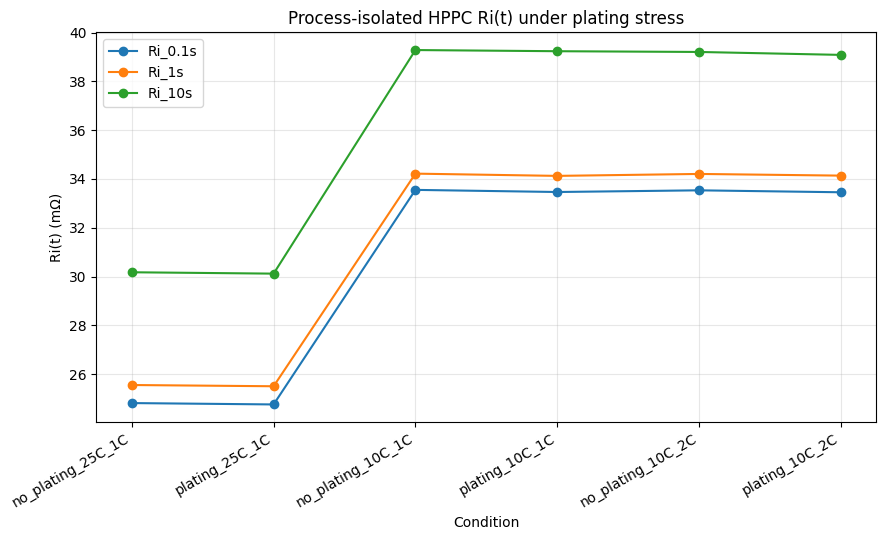

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/plating_26B_hppc_Ri_absolute.png


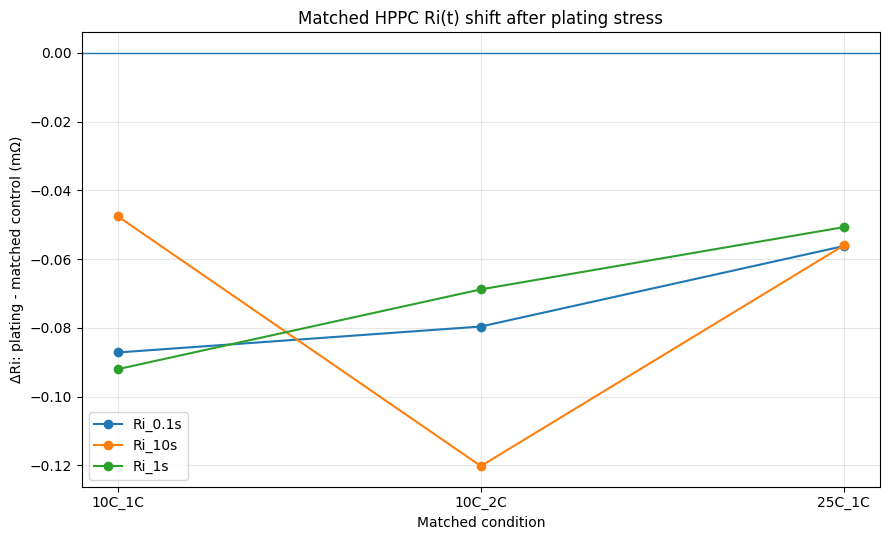

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/plating_26B_hppc_matched_Ri_shift.png


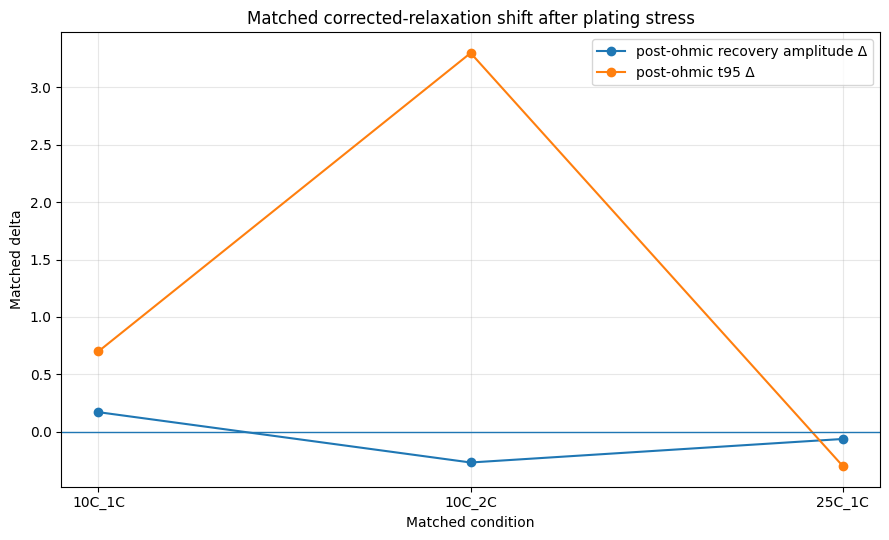

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/plating_26B_hppc_corrected_relaxation_shift.png
[OK] HPPC figures generated.


In [4]:
# Cell 4 — HPPC matched-audit figures
# （HPPC 匹配审计图像）

# Figure 1 — absolute Ri(t)
plt.figure(figsize=(9, 5.5))

for metric in ["Ri_0.1s_mOhm", "Ri_1s_mOhm", "Ri_10s_mOhm"]:
    plt.plot(
        plating_26B_hppc_descriptor_table["condition"].astype(str),
        plating_26B_hppc_descriptor_table[metric],
        marker="o",
        label=metric.replace("_mOhm", ""),
    )

plt.xticks(rotation=30, ha="right")
plt.ylabel("Ri(t) (mΩ)")
plt.xlabel("Condition")
plt.title("Process-isolated HPPC Ri(t) under plating stress")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

p = FIGURES / "plating_26B_hppc_Ri_absolute.png"
plt.savefig(p, dpi=300)
plt.show()
print(f"[OK] saved: {p}")


# Figure 2 — matched Ri delta
plot_rows = []

for _, row in plating_26B_matched_hppc_audit.iterrows():
    for metric in ["Ri_0.1s_mOhm", "Ri_1s_mOhm", "Ri_10s_mOhm"]:
        plot_rows.append({
            "pair": row["pair"],
            "metric": metric.replace("_mOhm", ""),
            "delta_mOhm": row[f"{metric}_delta_plating_minus_control"],
        })

ri_delta_plot = pd.DataFrame(plot_rows)

plt.figure(figsize=(9, 5.5))

for metric, g in ri_delta_plot.groupby("metric"):
    plt.plot(g["pair"], g["delta_mOhm"], marker="o", label=metric)

plt.axhline(0, linewidth=1)
plt.ylabel("ΔRi: plating - matched control (mΩ)")
plt.xlabel("Matched condition")
plt.title("Matched HPPC Ri(t) shift after plating stress")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

p = FIGURES / "plating_26B_hppc_matched_Ri_shift.png"
plt.savefig(p, dpi=300)
plt.show()
print(f"[OK] saved: {p}")


# Figure 3 — corrected relaxation delta
plt.figure(figsize=(9, 5.5))

plt.plot(
    plating_26B_matched_hppc_audit["pair"],
    plating_26B_matched_hppc_audit["post_ohmic_recovery_amplitude_mV_delta_plating_minus_control"],
    marker="o",
    label="post-ohmic recovery amplitude Δ",
)

plt.plot(
    plating_26B_matched_hppc_audit["pair"],
    plating_26B_matched_hppc_audit["post_ohmic_t95_s_delta_plating_minus_control"],
    marker="o",
    label="post-ohmic t95 Δ",
)

plt.axhline(0, linewidth=1)
plt.ylabel("Matched delta")
plt.xlabel("Matched condition")
plt.title("Matched corrected-relaxation shift after plating stress")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

p = FIGURES / "plating_26B_hppc_corrected_relaxation_shift.png"
plt.savefig(p, dpi=300)
plt.show()
print(f"[OK] saved: {p}")

print("[OK] HPPC figures generated.")

In [5]:
# Cell 5 — 26B HPPC classification
# （26B HPPC 分类）

# Load Phase A direct plating signals for context
phaseA_path = DATA / "plating_full_matched_capacity_audit.csv"
phaseA_available = phaseA_path.exists()

if phaseA_available:
    phaseA = pd.read_csv(phaseA_path)
else:
    phaseA = None

max_abs_Ri_delta = float(
    plating_26B_matched_hppc_audit[
        [f"{c}_delta_plating_minus_control" for c in RI_COLS]
    ].abs().max().max()
)

max_abs_relax_amp_delta = float(
    plating_26B_matched_hppc_audit[
        "post_ohmic_recovery_amplitude_mV_delta_plating_minus_control"
    ].abs().max()
)

max_abs_t95_delta = float(
    plating_26B_matched_hppc_audit[
        "post_ohmic_t95_s_delta_plating_minus_control"
    ].abs().max()
)

if max_abs_Ri_delta >= 1.0:
    ri_strength = "strong"
    ri_class = "plating stress produces measurable Ri(t) shift"
elif max_abs_Ri_delta >= 0.2:
    ri_strength = "weak-to-moderate"
    ri_class = "plating stress produces small Ri(t) shift"
else:
    ri_strength = "weak / near-zero"
    ri_class = "Ri(t) shift is small under tested plating stress"

if max_abs_relax_amp_delta >= 2.0 or max_abs_t95_delta >= 10.0:
    relax_strength = "data-backed"
    relax_class = "corrected relaxation changes are measurable"
else:
    relax_strength = "weak / near-zero"
    relax_class = "corrected relaxation changes are small under tested plating stress"

plating_26B_classification_table = pd.DataFrame([
    {
        "metric_layer": "process_isolation",
        "evidence": "All six HPPC conditions produced descriptor and segment-audit CSV files from external Python processes.",
        "strength": "strong",
        "classification": "process-isolated HPPC workflow solved the Jupyter kernel-death boundary",
    },
    {
        "metric_layer": "Ri_t",
        "evidence": f"Maximum absolute matched Ri(t) delta = {max_abs_Ri_delta:.6f} mΩ.",
        "strength": ri_strength,
        "classification": ri_class,
    },
    {
        "metric_layer": "corrected_relaxation",
        "evidence": (
            f"Max corrected recovery-amplitude delta = {max_abs_relax_amp_delta:.6f} mV; "
            f"max corrected t95 delta = {max_abs_t95_delta:.6f} s."
        ),
        "strength": relax_strength,
        "classification": relax_class,
    },
    {
        "metric_layer": "overall",
        "evidence": "HPPC Ri(t) and corrected relaxation layer was completed under process isolation.",
        "strength": "supported",
        "classification": "plating HPPC process-isolated audit completed",
    },
])

class_path = DATA / "plating_26B_classification_table.csv"
plating_26B_classification_table.to_csv(class_path, index=False)

print(f"[OK] saved: {class_path}")
display(plating_26B_classification_table)

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/plating_26B_classification_table.csv


,metric_layer,evidence,strength,classification
0,process_isolation,All six HPPC conditions produced descriptor an...,strong,process-isolated HPPC workflow solved the Jupy...
1,Ri_t,Maximum absolute matched Ri(t) delta = 0.12018...,weak / near-zero,Ri(t) shift is small under tested plating stress
2,corrected_relaxation,Max corrected recovery-amplitude delta = 0.268...,weak / near-zero,corrected relaxation changes are small under t...
3,overall,HPPC Ri(t) and corrected relaxation layer was ...,supported,plating HPPC process-isolated audit completed


In [6]:
# Cell 6 — Notebook 26B output inventory
# （Notebook 26B 输出文件清单）

expected_outputs = [
    DATA / "plating_26B_hppc_descriptor_table.csv",
    DATA / "plating_26B_segment_audit_table.csv",
    DATA / "plating_26B_matched_hppc_audit.csv",
    DATA / "plating_26B_classification_table.csv",
    FIGURES / "plating_26B_hppc_Ri_absolute.png",
    FIGURES / "plating_26B_hppc_matched_Ri_shift.png",
    FIGURES / "plating_26B_hppc_corrected_relaxation_shift.png",
]

inventory_rows = []

for p in expected_outputs:
    inventory_rows.append({
        "path": str(p.relative_to(REPO)),
        "exists": p.exists(),
        "size_kB": round(p.stat().st_size / 1024, 2) if p.exists() else np.nan,
    })

plating_26B_output_inventory = pd.DataFrame(inventory_rows)

inventory_path = DATA / "plating_26B_output_inventory.csv"
plating_26B_output_inventory.to_csv(inventory_path, index=False)

print(f"[OK] saved: {inventory_path}")
display(plating_26B_output_inventory)

assert plating_26B_output_inventory["exists"].all(), "Some expected Notebook 26B outputs are missing."

print("[OK] Notebook 26B output inventory complete.")

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/plating_26B_output_inventory.csv


,path,exists,size_kB
0,data/plating_26B_hppc_descriptor_table.csv,True,5.69
1,data/plating_26B_segment_audit_table.csv,True,4.07
2,data/plating_26B_matched_hppc_audit.csv,True,3.38
3,data/plating_26B_classification_table.csv,True,0.70
4,figures/plating_26B_hppc_Ri_absolute.png,True,168.38
5,figures/plating_26B_hppc_matched_Ri_shift.png,True,170.29
6,figures/plating_26B_hppc_corrected_relaxation_...,True,157.02


[OK] Notebook 26B output inventory complete.
